In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from evcouplings.compare import DistanceMap
import os
from collections import Counter
from evcouplings.compare import DistanceMap

In [13]:
allmuts = pd.read_csv("summary_data/02.all_mutations_analyzed.csv", index_col=0)
print(len(allmuts), "total residues mutated")
print(len(allmuts.uid.unique()), "total proteins")


330595 total residues mutated
3574 total proteins


### percent of residues mutated per protein

In [14]:
protein_data = pd.read_csv("summary_data/01.structure_hits.csv")
protein_data

grouped = allmuts.groupby("uid").sum()
total_muts = pd.DataFrame(grouped)

sites_mutated = pd.DataFrame(allmuts.groupby("uid").size(), columns=["sites_mutated"])
sites_mutated = sites_mutated.merge(protein_data[["uid", "filtered_length"]], on="uid", how="left")
sites_mutated["percent"] = sites_mutated.sites_mutated / sites_mutated.filtered_length
sites_mutated = sites_mutated.merge(total_muts, on="uid", how="left")



In [15]:
print("median number of mutations per protein", grouped.summed.median())
print("median number of mutations per site", allmuts.summed.median())
print("median number of sites mutated", allmuts.groupby("uid").size().median())

print("Mean sites mutated per protein (percent)", np.nanmean(sites_mutated.percent))
print("mean number of mutations per protein", grouped.summed.mean())
print("mean number of mutations per site", allmuts.summed.mean())
print("mean number of sites mutated", allmuts.groupby("uid").size().mean())
print("median percent of sites mutated", sites_mutated.percent.median())

median number of mutations per protein 102.0
median number of mutations per site 1.0
median number of sites mutated 77.5
Mean sites mutated per protein (percent) 0.3185704329573848
mean number of mutations per protein 130.2006155567991
mean number of mutations per site 1.407574222235666
mean number of sites mutated 92.5
median percent of sites mutated 0.32608695652173914


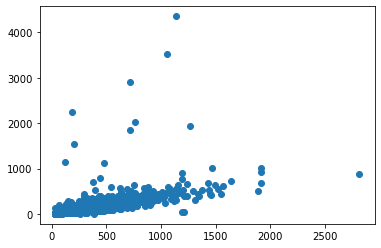

In [16]:
plt.scatter(sites_mutated.filtered_length, sites_mutated.summed)

In [17]:
positive_controls = ['RPOB_MYCTU', 'EMBB_MYCTU', 'KATG_MYCTU', 'PNCA_MYCTU', 'GYRA_MYCTU',
       'RPOC_MYCTU', 'RSMG_MYCTU', "ETHA_MYCTU", "RS12_MYCTU"]

sites_mutated_no_pos_control = sites_mutated.query("uid not in @positive_controls")
print(sites_mutated_no_pos_control.summed.sum()/sites_mutated_no_pos_control.filtered_length.sum())

0.4238277990989488


## Positive controls

In [18]:
expected_mutations_per_site = sites_mutated_no_pos_control.summed.sum()/sites_mutated_no_pos_control.filtered_length.sum()
print(expected_mutations_per_site)

0.4238277990989488


In [19]:
sites_mutated.query("uid=='EMBB_MYCTU'")

,uid,sites_mutated,filtered_length,percent,residue,summed
364,EMBB_MYCTU,413,1054.0,0.391841,224256,3518.0


In [20]:
uid_to_entry = {x:y for x,y in zip(allmuts.uid, allmuts.Entry)}
uid_to_rv = {x:y for x,y in zip(allmuts.uid, allmuts.rv)}
uid_to_len = {x:y for x,y in zip(sites_mutated.uid, sites_mutated.filtered_length)}

In [21]:
absolute_path = !pwd
absolute_path = absolute_path[0]

In [24]:
!mkdir controls
os.system("mkdir controls/positive_controls")

output_table = []

for protein in positive_controls:
    uid = protein
    muts= allmuts.query("uid == @protein")
    print(protein)
    print("NUmber of sites mutated", len(muts))
    print("Total mutations", muts.summed.sum())
    
    ### First step: determine which residues in the protein can be mutated
    dm = DistanceMap.from_file(f"{absolute_path}/filtered_distmaps/{uid_to_entry[uid]}")
    residues_to_sample = dm.residues_i

    # Add a column to the distance map residue dataframe with the observed number of mutations in that site
    # If none, add a pseudocount for expected mutations in that site
    residue_to_mutations = {i:N for i,N in zip(muts.residue, muts.summed)}
    residues_to_sample["num_mutations"] = expected_mutations_per_site
    
    for idx,row in residues_to_sample.iterrows():
        if int(row.id) in residue_to_mutations:
            residues_to_sample.loc[idx, "num_mutations"] = residue_to_mutations[int(row.id)]
            
            
    # Generate distribution of probability of sampling each residue
    num_residues_to_sample = np.int(expected_mutations_per_site * uid_to_len[uid])
    print(uid_to_len[uid], num_residues_to_sample)
    
    prob_mutation = np.array(residues_to_sample.num_mutations) / residues_to_sample.num_mutations.sum()

    #100 iterations
    for i in range(100):
        if not os.path.isdir(f"controls/positive_controls/{uid}_{i}"):
            os.system(f"mkdir controls/positive_controls/{uid}_{i}")
        
        residues = np.random.choice(
            np.array(residues_to_sample.id), 
            num_residues_to_sample,
            p = prob_mutation,
            replace=True
        )
        
        counts = Counter(residues)
        _df = pd.DataFrame({"residue":counts.keys(), "summed":counts.values()}, index=range(len(counts))).sort_values("summed", ascending=False)
#         

        _df.to_csv(f"controls/positive_controls/{uid}_{i}/mutations_analyzed.csv")
        output_table.append([f"{uid}_{i}", uid, i ,uid_to_entry[uid], uid_to_rv[uid]])

output_table = pd.DataFrame(output_table, columns=["id", "uid", "iteration", "Entry", "rv"])
output_table.to_csv("controls/positive_control_set.csv")

mkdir: cannot create directory ‘controls’: File exists
RPOB_MYCTU
NUmber of sites mutated 388
Total mutations 4355.0


mkdir: cannot create directory ‘controls/positive_controls’: File exists
/tmp/ipykernel_11186/767981758.py:27: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  num_residues_to_sample = np.int(expected_mutations_per_site * uid_to_len[uid])


1138.0 482
EMBB_MYCTU
NUmber of sites mutated 413
Total mutations 3518.0
1054.0 446


/tmp/ipykernel_11186/767981758.py:27: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  num_residues_to_sample = np.int(expected_mutations_per_site * uid_to_len[uid])


KATG_MYCTU
NUmber of sites mutated 419
Total mutations 2917.0


...

/tmp/ipykernel_11186/767981758.py:27: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  num_residues_to_sample = np.int(expected_mutations_per_site * uid_to_len[uid])


ETHA_MYCTU
NUmber of sites mutated 352
Total mutations 1117.0
482.0 204


/tmp/ipykernel_11186/767981758.py:27: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  num_residues_to_sample = np.int(expected_mutations_per_site * uid_to_len[uid])


RS12_MYCTU
NUmber of sites mutated 27
Total mutations 1152.0
122.0 51


/tmp/ipykernel_11186/767981758.py:27: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  num_residues_to_sample = np.int(expected_mutations_per_site * uid_to_len[uid])


## Create random negative controls

In [26]:
!mkdir controls/negative_controls_random
output_table = []
for protein in positive_controls:
    uid = protein
    muts= allmuts.query("uid == @protein")

    ### First step: determine which residues in the protein can be mutated
    dm = DistanceMap.from_file(f"{absolute_path}/filtered_distmaps/{uid_to_entry[uid]}")
    residues_to_sample = dm.residues_i

    # Add a column to the distance map residue dataframe with the observed number of mutations in that site
    # If none, add a pseudocount for expected mutations in that site
    residue_to_mutations = {i:N for i,N in zip(muts.residue, muts.summed)}
    residues_to_sample["num_mutations"] = expected_mutations_per_site
                      
    # Generate distribution of probability of sampling each residue
    num_residues_to_sample = np.int(expected_mutations_per_site * uid_to_len[uid])
    print(uid_to_len[uid], num_residues_to_sample)
    
    prob_mutation = np.array(residues_to_sample.num_mutations) / residues_to_sample.num_mutations.sum()

    
    #100 iterations
    for i in range(100):
        
        if not os.path.isdir(f"controls/negative_controls_random/{uid}_{i}"):
            os.system(f"mkdir controls/negative_controls_random/{uid}_{i}")

        
        residues = np.random.choice(
            np.array(residues_to_sample.id), 
            num_residues_to_sample,
            p = prob_mutation,
            replace=True
        )
        
        counts = Counter(residues)
        _df = pd.DataFrame({"residue":counts.keys(), "summed":counts.values()}, index=range(len(counts))).sort_values("summed", ascending=False)

        _df.to_csv(f"controls/negative_controls_random/{protein}_{i}/mutations_analyzed.csv")
        output_table.append([f"{uid}_{i}", uid, i ,uid_to_entry[uid], uid_to_rv[uid]])
        
output_table = pd.DataFrame(output_table, columns=["id", "uid", "iteration", "Entry", "rv"])
output_table.to_csv("controls/negative_controls_random_set.csv")

mkdir: cannot create directory ‘controls/negative_controls_random’: File exists
1138.0 482


/tmp/ipykernel_11186/2990640108.py:17: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  num_residues_to_sample = np.int(expected_mutations_per_site * uid_to_len[uid])
/tmp/ipykernel_11186/2990640108.py:17: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for add

1054.0 446


/tmp/ipykernel_11186/2990640108.py:17: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  num_residues_to_sample = np.int(expected_mutations_per_site * uid_to_len[uid])


716.0 303


...

202.0 85


/tmp/ipykernel_11186/2990640108.py:17: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  num_residues_to_sample = np.int(expected_mutations_per_site * uid_to_len[uid])


482.0 204


/tmp/ipykernel_11186/2990640108.py:17: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  num_residues_to_sample = np.int(expected_mutations_per_site * uid_to_len[uid])


122.0 51


In [ ]:
_df